Dataset Shape after cleaning: (9357, 13)


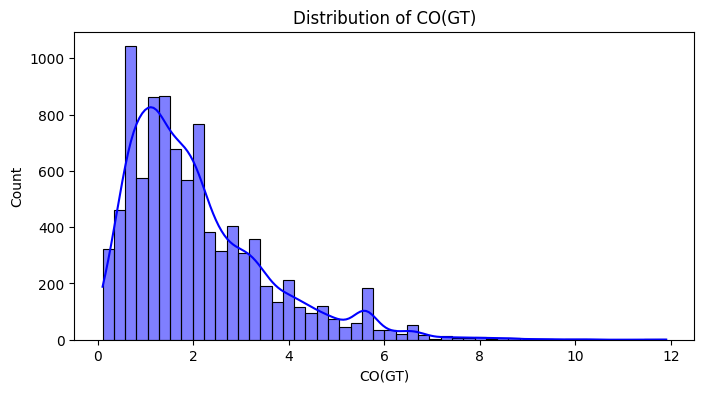

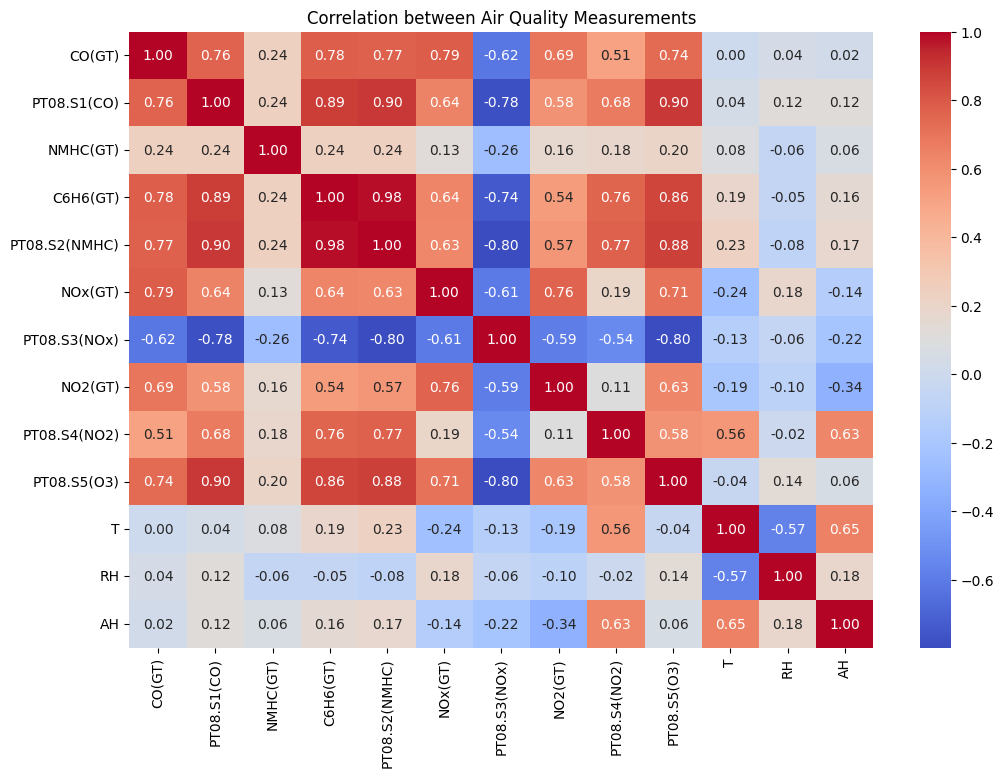


--- Model Evaluation ---
MAE: 0.3010
MSE: 0.2298
RMSE: 0.4794
R2 Score: 0.8787


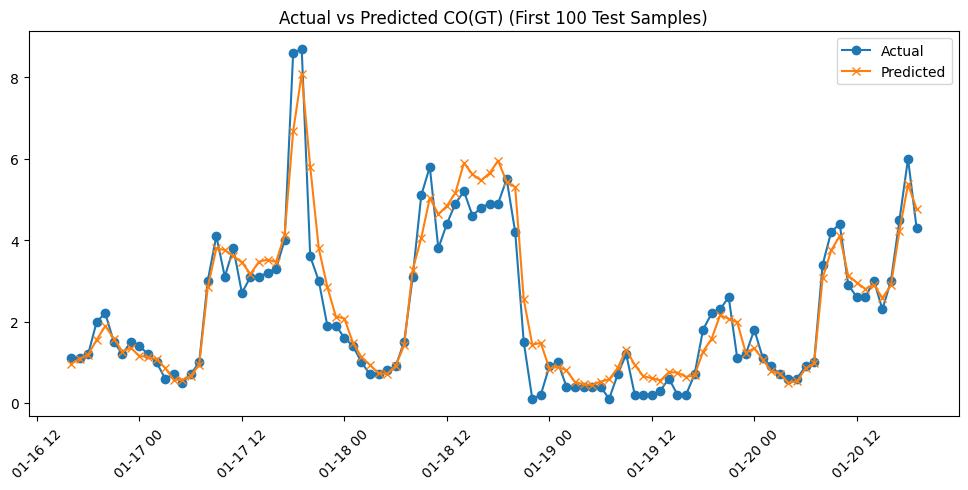

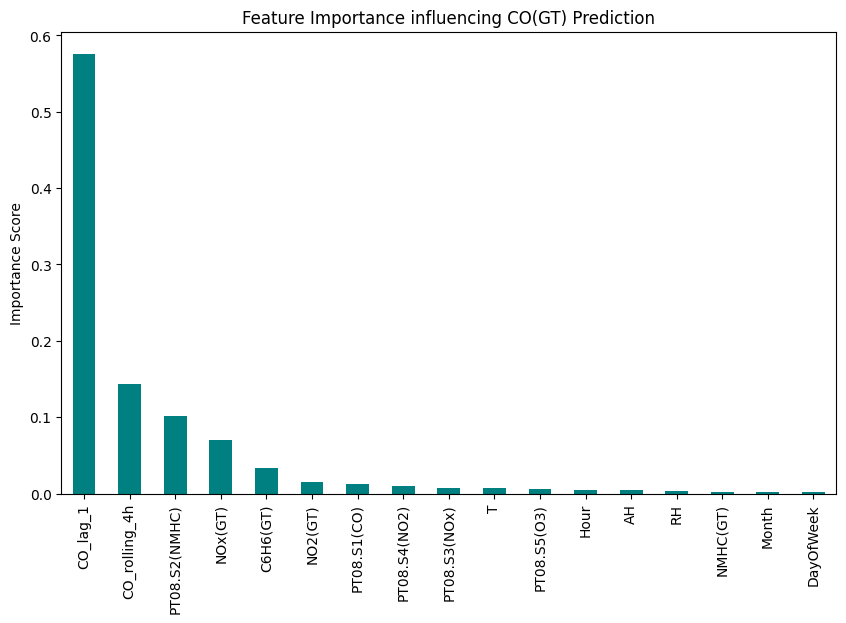

In [3]:
# ==========================================
# TASK 1: AIR QUALITY FORECASTING
# ==========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# PART A: Data Understanding & Preprocessing
# ---------------------------------------------------------

# 1. Load the dataset (The UCI dataset uses ';' as a separator and ',' for decimals)
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')

# 2. Drop completely empty rows and columns that appear at the end of the raw CSV
df = df.dropna(how='all', axis=1)
df = df.dropna(how='all', axis=0)

# 3. Handle Time-related information
# Combine Date and Time into a single Datetime column and set it as the index
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
df = df.set_index('Datetime')
df = df.drop(columns=['Date', 'Time'])

# 4. Handle Missing Values
# In this dataset, -200 represents missing/invalid sensor readings. Replace with NaN.
df = df.replace(-200, np.nan)

# Forward-fill missing values (since air quality changes gradually over time)
df = df.ffill()
df = df.dropna() # Drop any lingering NaNs at the very first row

print("Dataset Shape after cleaning:", df.shape)

# ---------------------------------------------------------
# PART B: Exploratory Data Analysis
# ---------------------------------------------------------

# 1. Plot the distribution of Carbon Monoxide (CO(GT))
plt.figure(figsize=(8, 4))
sns.histplot(df['CO(GT)'], bins=50, kde=True, color='blue')
plt.title('Distribution of CO(GT)')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between Air Quality Measurements')
plt.show()

# ---------------------------------------------------------
# PART C: Feature Engineering
# ---------------------------------------------------------

# Target variable to predict
target = 'CO(GT)'

# 1. Time-based features
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month

# 2. Lagged features (Pollution level from 1 hour ago)
df['CO_lag_1'] = df[target].shift(1)

# 3. Rolling average (Average pollution of the last 4 hours)
df['CO_rolling_4h'] = df[target].rolling(window=4).mean()

# Drop rows with NaNs created by the shifting/rolling operations
df = df.dropna()

# ---------------------------------------------------------
# PART D: Prediction (Chronological Split)
# ---------------------------------------------------------

# 1. Define Features (X) and Target (y)
X = df.drop(columns=[target])
y = df[target]

# 2. Chronological Train-Test Split (DO NOT use random shuffling to avoid data leakage)
split_idx = int(len(df) * 0.8) # 80% train, 20% test

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 3. Build and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluate the model
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\n--- Model Evaluation ---")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

# ---------------------------------------------------------
# PART E: Analysis
# ---------------------------------------------------------

# 1. Actual vs Predicted Plot (Zoomed in on the first 100 test samples for clarity)
plt.figure(figsize=(12, 5))
plt.plot(y_test.index[:100], y_test.values[:100], label='Actual', marker='o')
plt.plot(y_test.index[:100], y_pred[:100], label='Predicted', marker='x')
plt.title('Actual vs Predicted CO(GT) (First 100 Test Samples)')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# 2. Feature Importance Plot
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importance.plot(kind='bar', color='teal')
plt.title('Feature Importance influencing CO(GT) Prediction')
plt.ylabel('Importance Score')
plt.show()

## PART E: Analysis
* **Prediction Performance:** The model performs exceptionally well, achieving an $R^2$ score of 0.8787. Looking at the Actual vs Predicted plot, the model successfully tracks the general flow and daily seasonality of CO(GT) levels.
* **Error Analysis:** The model makes its largest errors during sudden, sharp spikes in pollution (the highest peaks on the graph). It tends to slightly under-predict these extreme anomalies.
* **Feature Importance:** The most influential feature by far is `CO_lag_1` (pollution level 1 hour ago), followed by the 4-hour rolling average. This proves that recent historical context is much more valuable for prediction than standard temporal features like the hour or day of the week.
* **Avoiding Data Leakage:** In time-series forecasting, data leakage occurs if the model is allowed to "peek" at future data during training. I avoided this by using a strict chronological split (`iloc[:split_idx]`) instead of a random train-test split, ensuring the model only trained on past data to predict future data.

## PART F: Insights & Limitations
**Key Findings:**
1. The dataset contains 9,357 records, and the distribution of CO(GT) is right-skewed, meaning most hours have low pollution, with occasional severe spikes.
2. CO(GT) has strong positive correlations with other pollutants like Benzene (C6H6) and NOx, but a strong negative correlation with PT08.S3(NOx).
3. The Random Forest model achieved a highly accurate $R^2$ of 0.8787 and a low MAE of 0.3010.
4. Historical context (`CO_lag_1` and `CO_rolling_4h`) proved far more predictive than raw time components (Hour/Month).

**Limitations:**
1. The model struggles to perfectly capture sudden, extreme pollution peaks.
2. The forward-filling method for missing data, while necessary, might artificially smooth out sudden drops or spikes in the real data.

**Future Improvements:**
Incorporating external variables, such as traffic volume data or local weather conditions (wind speed, precipitation), could help the model predict sudden spikes that historical pollution data alone cannot foresee.
